In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
train_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Datasets/fashionmnist/fashion-mnist_train.csv")
test_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Datasets/fashionmnist/fashion-mnist_test.csv")

print(train_data.shape)
print(test_data.shape)

(60000, 785)
(10000, 785)


In [3]:
X_train = train_data.drop("label", axis=1).values
y_train = train_data["label"].values

X_test = test_data.drop("label", axis=1).values
y_test = test_data["label"].values

In [4]:
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape to 28x28x1
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [5]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

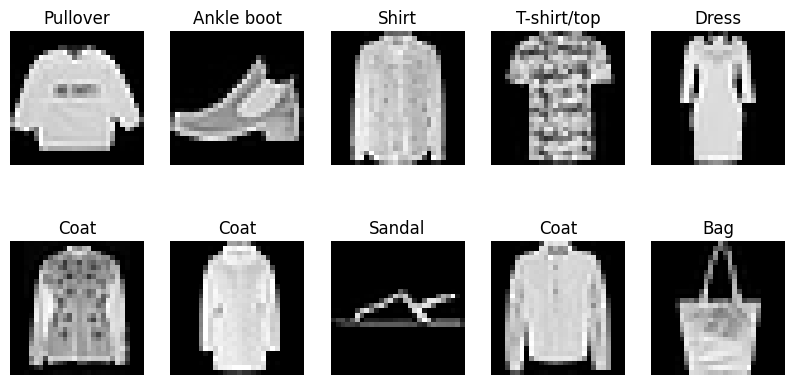

In [6]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()

In [7]:
model = models.Sequential([
    layers.Input(shape=(28,28,1)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Better than Flatten
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, y_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 123ms/step - accuracy: 0.5354 - loss: 1.2416 - val_accuracy: 0.7046 - val_loss: 0.8134
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 75s 109ms/step - accuracy: 0.6930 - loss: 0.8426 - val_accuracy: 0.7390 - val_loss: 0.7051
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 114ms/step - accuracy: 0.7192 - loss: 0.7658 - val_accuracy: 0.7546 - val_loss: 0.6505
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 51s 108ms/step - accuracy: 0.7395 - loss: 0.7146 - val_accuracy: 0.7629 - val_loss: 0.6160
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 51s 108ms/step - accuracy: 0.7514 - loss: 0.6782 - val_accuracy: 0.7867 - val_loss: 0.5765
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 108ms/step - accuracy: 0.7628 - loss: 0.6508 - val_accuracy: 0.7880 - val_loss: 0.5597
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 110ms/step - accuracy: 0.7721 - loss: 0.6255 - val_accuracy: 0.7958 - val_loss: 0.5420
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 113ms/step - accuracy: 0.7800 - loss: 0

In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8111 - loss: 0.4966
Test Accuracy: 0.8111000061035156


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


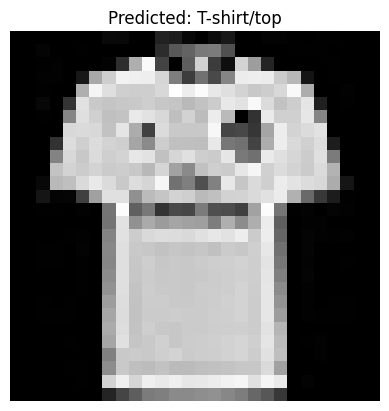

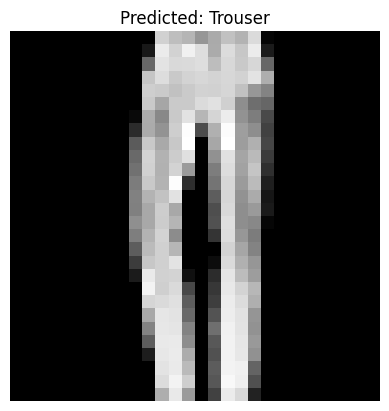

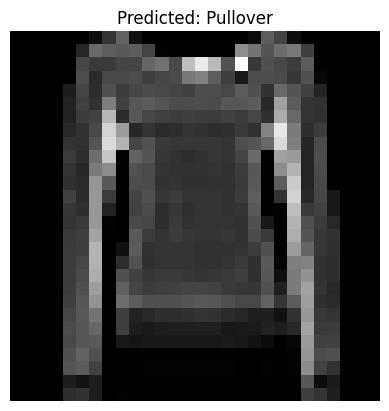

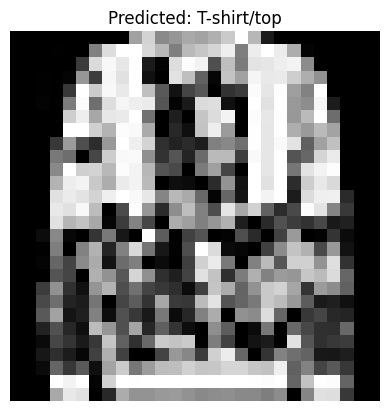

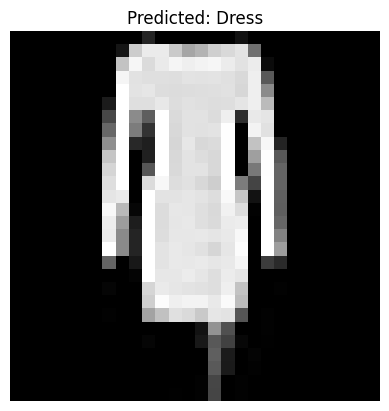

In [11]:
predictions = model.predict(X_test)

for i in range(5):
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title("Predicted: " + class_names[np.argmax(predictions[i])])
    plt.axis('off')
    plt.show()

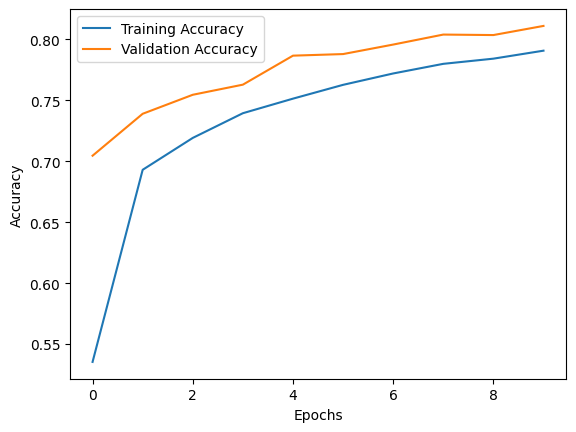

In [12]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()